In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
users = pd.read_csv("data/users.csv")
videos = pd.read_csv("data/videos.csv")
events = pd.read_csv("data/events.csv")

In [4]:
event_counts = events["event_type"].value_counts()
print(event_counts)

event_type
View       499207
Like       124865
Comment     39915
Share       14853
Follow       9892
Name: count, dtype: int64


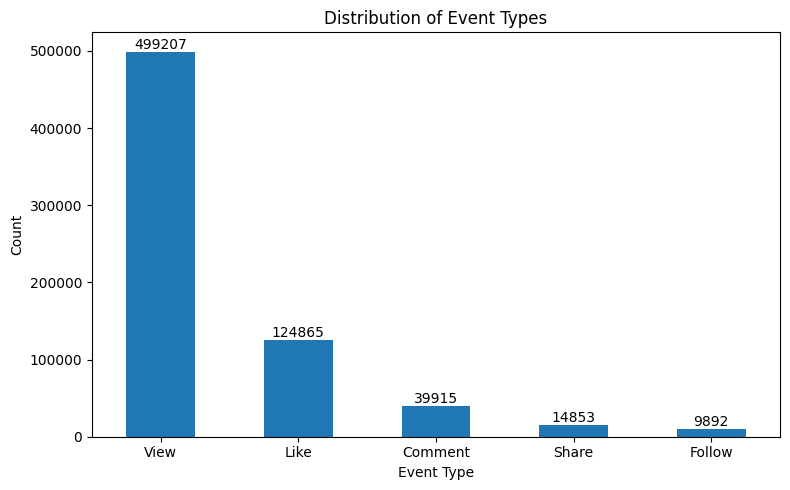

In [5]:
ax = event_counts.plot(kind="bar", figsize=(8,5))

plt.title("Distribution of Event Types")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [6]:
engagement_events = events[
    events["event_type"].isin(["Like", "Comment", "Share", "Follow"])
]

engagement_count = len(engagement_events)

print(engagement_count)

189525


In [7]:
total_events = len(events)

engagement_rate = (engagement_count / total_events) * 100

print(f"Overall Engagement Rate: {engagement_rate:.2f}%")

Overall Engagement Rate: 27.52%


In [8]:
views = (
    events[events["event_type"] == "View"]
    .groupby("video_id")
    .size()
    .reset_index(name="views")
)

In [9]:
likes = (
    events[events["event_type"] == "Like"]
    .groupby("video_id")
    .size()
    .reset_index(name="likes")
)

In [10]:
video_engagement = views.merge(
    likes,
    on="video_id",
    how="left"
)

In [11]:
video_engagement["likes"] = video_engagement["likes"].fillna(0)

In [12]:
video_engagement["like_rate"] = (
    video_engagement["likes"] /
    video_engagement["views"]
) * 100

In [13]:
top_videos = (
    video_engagement
    .sort_values(by="like_rate", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print(top_videos)

  video_id  views  likes  like_rate
0   V00064     93     41  44.086022
1   V02379     96     41  42.708333
2   V01158    101     42  41.584158
3   V04503     95     39  41.052632
4   V03064     94     38  40.425532
5   V01094    109     44  40.366972
6   V01488    108     43  39.814815
7   V01381     94     36  38.297872
8   V00027     94     36  38.297872
9   V02568    108     41  37.962963


In [14]:
#Which users performed the highest number of engagement actions (Like, Comment, Share, Follow)?
engaged_users = (
    events[
        events["event_type"].isin(["Like", "Share", "Comment", "Follow"])
    ]
    .groupby("user_id")
    .size()
    .reset_index(name="engagement_count")
)



In [15]:
top_users=(engaged_users
          .sort_values(by="engagement_count",ascending=False)
          .head(10)
          .reset_index(drop=True)
         )
print(top_users)

  user_id  engagement_count
0  U02672                47
1  U01111                46
2  U02449                46
3  U04751                46
4  U06623                46
5  U04765                44
6  U06590                44
7  U02764                43
8  U02564                42
9  U07263                42


In [16]:
merged_df = events.merge(
    videos,
    on="video_id",
    how="inner"
)

In [17]:
merged_df["watch_time_sec"] = pd.to_numeric(
    merged_df["watch_time_sec"],
    errors="coerce"
)
merged_df["watch_time_sec"].dtype

dtype('float64')

In [18]:
view_events = merged_df[merged_df["event_type"] == "View"]

print(view_events[["category", "watch_time_sec"]].head())

    category  watch_time_sec
0      Music            31.0
2     Comedy            61.0
4  Education           117.0
5  Education           147.0
6       Food            61.0


In [19]:
view_events.groupby("category")["watch_time_sec"].mean()

category
Comedy        46.553799
Education     48.355409
Fashion       48.553560
Food          49.113056
Gaming        50.597479
Music         47.918075
News          47.135060
Sports        48.874615
Technology    47.554170
Travel        49.300671
Name: watch_time_sec, dtype: float64

In [20]:
#Which content categories have the highest average watch time?
avg_watch_time = (
    view_events
    .groupby("category")["watch_time_sec"]
    .mean()
    .reset_index(name="avg_watch_time")
)

top_watches = (
    avg_watch_time
    .sort_values(by="avg_watch_time", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print(top_watches)

     category  avg_watch_time
0      Gaming       50.597479
1      Travel       49.300671
2        Food       49.113056
3      Sports       48.874615
4     Fashion       48.553560
5   Education       48.355409
6       Music       47.918075
7  Technology       47.554170
8        News       47.135060
9      Comedy       46.553799


In [21]:
#Which creators have the highest total views?
view_events = merged_df[merged_df["event_type"] == "View"]
creator_views = (
    view_events
    .groupby("creator_id")
    .agg(
        total_views=("video_id", "count")
    )
    .sort_values("total_views",ascending=False)
    .head(10)
    .reset_index()
                )
print(creator_views)

  creator_id  total_views
0      C0887         1428
1      C0526         1255
2      C0069         1226
3      C0005         1138
4      C0852         1124
5      C0860         1123
6      C0525         1119
7      C0373         1111
8      C0654         1096
9      C0763         1091


In [22]:
#Which devices do users use the most?
device_percentage = (
    users["device"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

print(device_percentage)

    device  proportion
0  Android       60.43
1      iOS       34.97
2      Web        4.60


In [23]:
merged_df = (
    events
    .merge(videos, on="video_id", how="inner")
    .merge(users[["user_id", "device"]], on="user_id", how="inner")
)

merged_df["watch_time_sec"] = pd.to_numeric(
    merged_df["watch_time_sec"],
    errors="coerce"
)

In [24]:
#What is the average watch time for each category on each device?
pd.pivot_table(
    data=merged_df,
    index="category",
    columns="device",
    values="watch_time_sec",
    aggfunc="mean"
)

device,Android,Web,iOS
category,,,
Comedy,46.517420,47.250221,46.525428
Education,48.396439,47.829501,48.353818
Fashion,48.517069,48.940014,48.566050
Food,49.345252,47.304945,48.948413
Gaming,50.476816,50.869677,50.772688
Music,47.856523,48.710131,47.923201
News,47.097154,46.992899,47.219318
Sports,48.856598,49.131579,48.871957
Technology,47.514263,48.283264,47.526102


In [25]:
#Daily Active Users (DAU)
merged_df["date"] = pd.to_datetime(merged_df["timestamp"]).dt.date

active_users = (
    merged_df[merged_df["event_type"] == "View"]
    .groupby("date")["user_id"]
    .nunique()
    .reset_index(name="daily_active_users")
    .sort_values(by="date")
)

print(active_users)

           date  daily_active_users
0    2025-01-01                   3
1    2025-01-02                   9
2    2025-01-03                  15
3    2025-01-04                  15
4    2025-01-05                  20
..          ...                 ...
556  2026-07-11                 988
557  2026-07-12                 984
558  2026-07-13                1013
559  2026-07-14                 977
560  2026-07-15                 774

[561 rows x 2 columns]


In [26]:
#Which content categories receive the highest engagement?
views = (
    merged_df[merged_df["event_type"] == "View"]
    .groupby("category")
    .size()
    .reset_index(name="views")
)

engagement = (
    merged_df[
        merged_df["event_type"].isin(
            ["Like", "Comment", "Share", "Follow"]
        )
    ]
    .groupby("category")
    .size()
    .reset_index(name="engagements")
)

In [27]:
engagement["views"] = engagement["category"].map(
    views.set_index("category")["views"]
)

In [28]:
engagement["engagement_rate"] = (
    engagement["engagements"] /
    engagement["views"]
) * 100

In [29]:
engagement = (engagement.sort_values(
    by="engagement_rate",
    ascending=False)
    .reset_index(drop=True)
)

engagement


,category,engagements,views,engagement_rate
0,Gaming,19454,50611,38.438284
1,Education,19079,49903,38.232170
2,News,14356,37761,38.018061
3,Sports,20013,52662,38.002734
4,Technology,15693,41314,37.984703
5,Fashion,12156,32011,37.974446
6,Music,34330,90497,37.934959
7,Travel,12144,32035,37.908538
8,Comedy,27997,74025,37.821006
9,Food,14303,38388,37.259039


In [30]:
#Which individual videos are the most engaging?
views = (
    merged_df[merged_df["event_type"] == "View"]
    .groupby("video_id")
    .size()
    .reset_index(name="views")
)

engagement = (
    merged_df[
        merged_df["event_type"].isin(
            ["Like", "Comment", "Share", "Follow"]
        )
    ]
    .groupby("video_id")
    .size()
    .reset_index(name="engagements")
)

engagement_rate = views.merge(
    engagement,
    how="inner",
    on="video_id"
)

engagement_rate["engagement_rate"] = (
    engagement_rate["engagements"] /
    engagement_rate["views"]
) * 100

engagement_rate = (
    engagement_rate
    .sort_values(
        by="engagement_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

engagement_rate.head(10)

,video_id,views,engagements,engagement_rate
0,V00064,93,57,61.290323
1,V01381,94,56,59.574468
2,V01094,109,64,58.715596
3,V01158,101,58,57.425743
4,V00105,95,54,56.842105
5,V01871,95,53,55.789474
6,V02551,106,59,55.660377
7,V00541,94,52,55.319149
8,V02379,96,53,55.208333
9,V04663,85,46,54.117647


In [31]:
#How many engagement actions happen each day?
engagement = (
    merged_df[
        merged_df["event_type"].isin(
            ["Like", "Comment", "Share", "Follow"]
        )
    ]
    .groupby("date")
    .size()
    .reset_index(name="engagements")
    .sort_values("date")
    .reset_index(drop=True)
)
print(engagement)

           date  engagements
0    2025-01-01            2
1    2025-01-02            3
2    2025-01-03            7
3    2025-01-04            7
4    2025-01-05            8
..          ...          ...
556  2026-07-11          366
557  2026-07-12          394
558  2026-07-13          409
559  2026-07-14          415
560  2026-07-15          306

[561 rows x 2 columns]


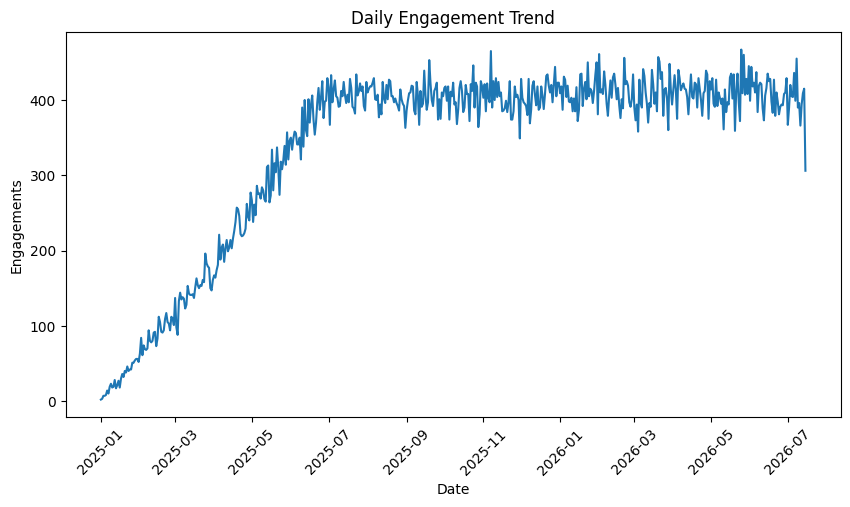

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    engagement["date"],
    engagement["engagements"]
)

plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Engagements")

plt.xticks(rotation=45)

plt.show()

In [33]:
#How many unique users were active each month?
merged_df["year_month"] = pd.to_datetime(
    merged_df["timestamp"]
).dt.to_period("M")

mau = (
    merged_df
    .groupby("year_month")["user_id"]
    .nunique()
    .reset_index(name="monthly_active_users")
)
print(mau)

   year_month  monthly_active_users
0     2025-01                  1249
1     2025-02                  2701
2     2025-03                  4386
3     2025-04                  6061
4     2025-05                  7854
5     2025-06                  9421
6     2025-07                  9740
7     2025-08                  9715
8     2025-09                  9684
9     2025-10                  9690
10    2025-11                  9670
11    2025-12                  9718
12    2026-01                  9741
13    2026-02                  9637
14    2026-03                  9696
15    2026-04                  9710
16    2026-05                  9724
17    2026-06                  9673
18    2026-07                  8463


In [34]:
mau["year_month"] = mau["year_month"].astype(str)

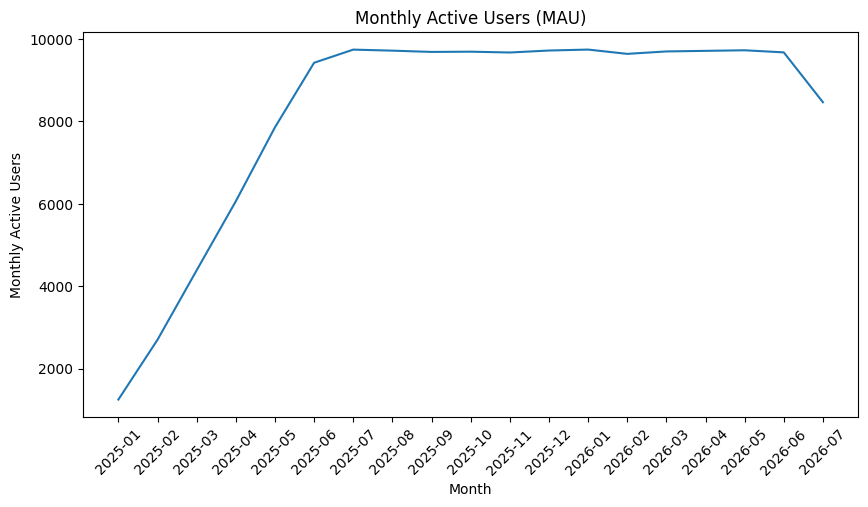

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    mau["year_month"],
    mau["monthly_active_users"]
)

plt.title("Monthly Active Users (MAU)")
plt.xlabel("Month")
plt.ylabel("Monthly Active Users")

plt.xticks(rotation=45)

plt.show()

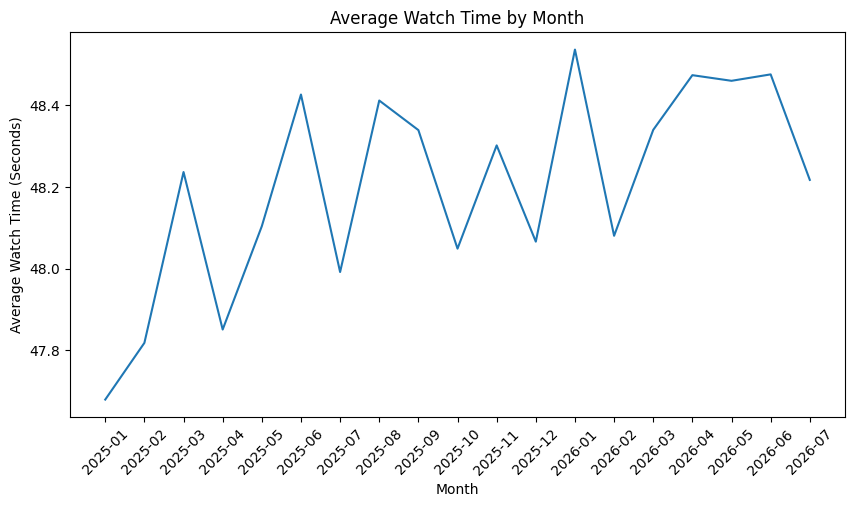

In [36]:
#How does the average watch time change from month to month?
avg_watch_time = (
    merged_df
    .groupby("year_month")["watch_time_sec"]
    .mean()
    .reset_index(name="average_watch_time")
)

avg_watch_time["year_month"] = avg_watch_time["year_month"].astype(str)

plt.figure(figsize=(10, 5))

plt.plot(
    avg_watch_time["year_month"],
    avg_watch_time["average_watch_time"]
)

plt.title("Average Watch Time by Month")
plt.xlabel("Month")
plt.ylabel("Average Watch Time (Seconds)")

plt.xticks(rotation=45)

plt.show()

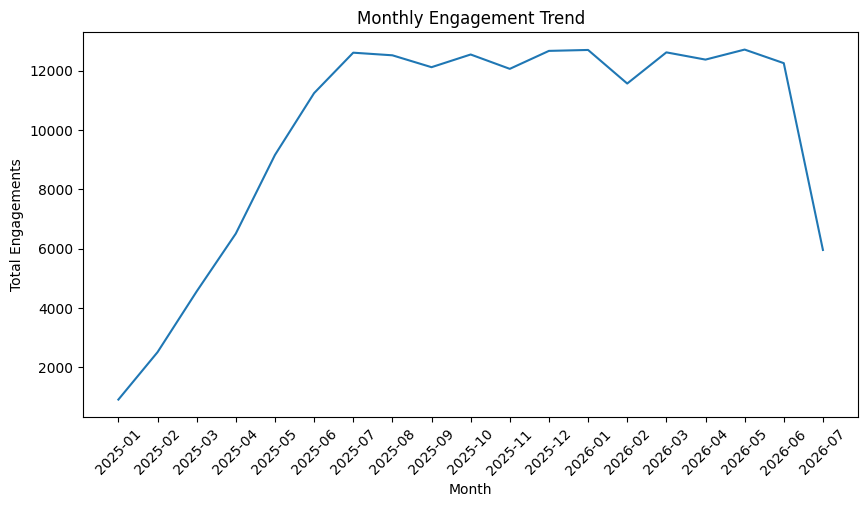

In [37]:
#How has total user engagement changed month by month?
monthly_engagement = (
    merged_df[
        merged_df["event_type"].isin(
            ["Like", "Comment", "Share", "Follow"]
        )
    ]
    .groupby("year_month")
    .size()
    .reset_index(name="engagements")
)

monthly_engagement["year_month"] = (
    monthly_engagement["year_month"].astype(str)
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_engagement["year_month"],
    monthly_engagement["engagements"]
)

plt.title("Monthly Engagement Trend")
plt.xlabel("Month")
plt.ylabel("Total Engagements")

plt.xticks(rotation=45)

plt.show()

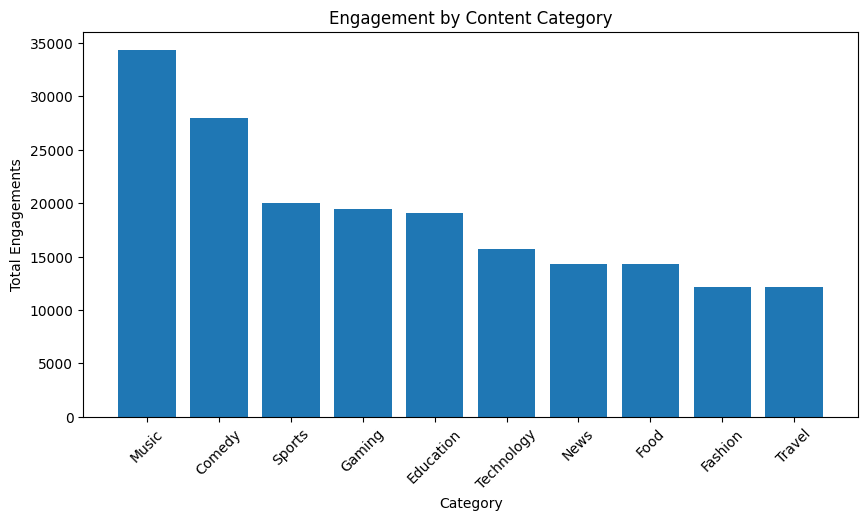

In [38]:
#Which content categories generate the highest engagement?
category_engagement = (
    merged_df[
        merged_df["event_type"].isin(
            ["Like", "Comment", "Share", "Follow"]
        )
    ]
    .groupby("category")
    .size()
    .reset_index(name="engagements")
    .sort_values("engagements", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))

plt.bar(
    category_engagement["category"],
    category_engagement["engagements"]
)

plt.title("Engagement by Content Category")
plt.xlabel("Category")
plt.ylabel("Total Engagements")

plt.xticks(rotation=45)

plt.show()

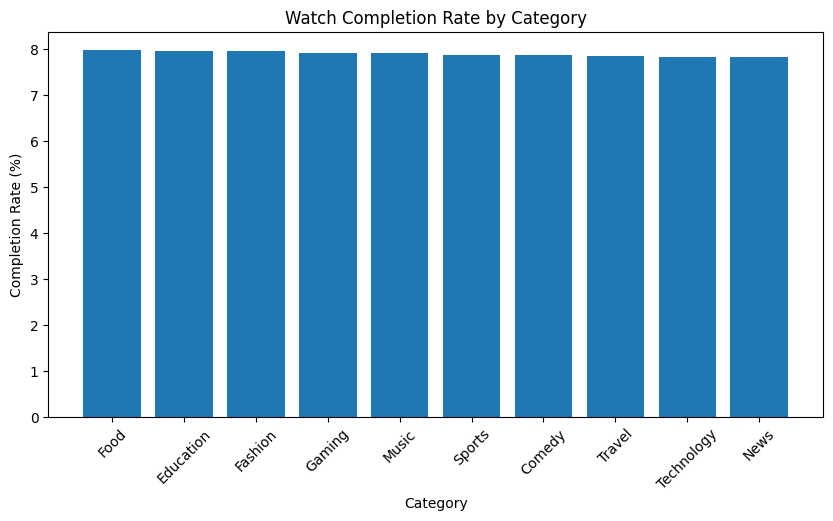

In [39]:
#Which content categories have the highest watch completion rate?

completion_rate = (
    merged_df
    .groupby("category")["watch_completed"]
    .mean()
    .reset_index(name="completion_rate")
    .sort_values("completion_rate", ascending=False)
    .reset_index(drop=True)
)

completion_rate["completion_rate"] = (
    completion_rate["completion_rate"] * 100
)

plt.figure(figsize=(10, 5))

plt.bar(
    completion_rate["category"],
    completion_rate["completion_rate"]
)

plt.title("Watch Completion Rate by Category")
plt.xlabel("Category")
plt.ylabel("Completion Rate (%)")

plt.xticks(rotation=45)

plt.show()

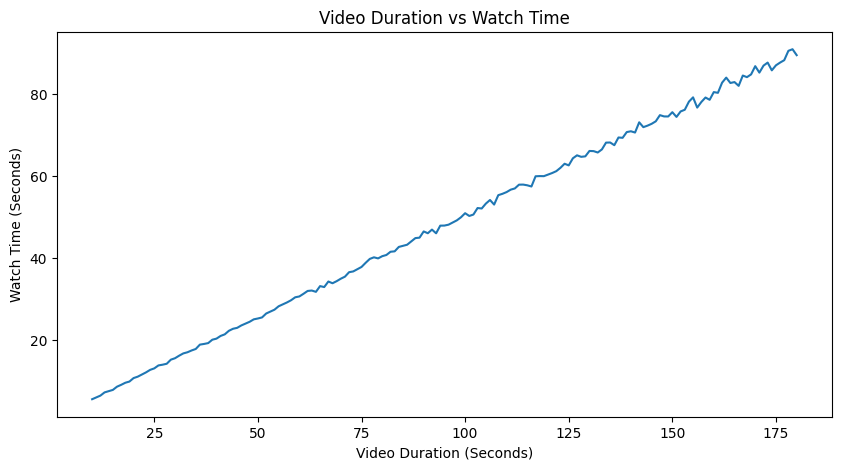

In [40]:
#Is there a relationship between a video's duration and how long users watch it?
duration_analysis = (
    merged_df
    .groupby("duration_sec")["watch_time_sec"]
    .mean()
    .reset_index(name="avg_watch_time")
)

plt.figure(figsize=(10, 5))

plt.plot(
    duration_analysis["duration_sec"],
    duration_analysis["avg_watch_time"]
)

plt.title("Video Duration vs Watch Time")
plt.xlabel("Video Duration (Seconds)")
plt.ylabel("Watch Time (Seconds)")

plt.show()

In [41]:
merged_df.to_csv("merged_data.csv", index=False)